# Model 2 (Single Imbalance Price) — Robust LDR: Run & Diagnostics

Runs `model_2_robust.py`, validates the reformulation against the vertex-enumeration oracle, and graphs:
1. the **gap check** (robust vs. oracle — must be ≈ 0),
2. the nominal schedule and bid against prices,
3. realised **SOC / charge / discharge fans** over the sample scenarios,
4. the recourse matrices $D^{ch}, D^{dis}, \Gamma = D^{ch}-D^{dis}$ as heatmaps,
5. the **$\rho$-sweep** (recourse dying as $\Xi'$ widens),
6. a **$k$-sweep** (economics vs. imbalance-tracking trade-off),
7. **wash-flow diagnostics** at the box vertices.

Requires `model_2_robust.py` in the same directory, plus `cvxpy`, `numpy`, `matplotlib`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import replace
from itertools import product
import cvxpy as cp

from single_price_robust_old import Params, Vars, build_robust, build_vertex, _soc_affine, report

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(0)

## 1. Base instance ($T=6$ — small enough for the $2^T$ oracle)

In [2]:
T = 6
P = Params(
    T_total=T, dt=1.0, eta_ch=0.95, eta_dis=0.95,
    C_ch=2.0, C_dis=2.0, B_max=6.0, SOC0=3.0,
    pl_hat=np.array([1., 3., 4., 2., 3., 1.]),
    pi_da=np.array([50., 80., 120., 60., 90., 40.]),
    pi_imb=np.array([70., 90., 40., 100., 55., 85.]),
    h_plus=np.full(T, 0.8), h_minus=np.full(T, 0.8),
    xi_samples=np.clip(rng.normal(0.1, 0.3, size=(T, 200)), -0.8, 0.8),
    k=0.5,
)

prob_r, v_r = build_robust(P)
prob_r.solve(solver=cp.CLARABEL)
print(f"robust counterpart : {prob_r.status}, obj = {prob_r.value:.8f} "
      f"({prob_r.size_metrics.num_scalar_variables} vars)")

prob_v, v_v = build_vertex(P)          # 2^6 = 64 corners
prob_v.solve(solver=cp.CLARABEL)
print(f"vertex oracle      : {prob_v.status}, obj = {prob_v.value:.8f} "
      f"({prob_v.size_metrics.num_scalar_variables} vars)")

gap = abs(prob_r.value - prob_v.value)
print(f"GAP                : {gap:.3e}")
assert gap < 1e-5, "ORACLE DISAGREES — semantic bug in the robust build; stop here."
print("Oracle gate PASSED — reformulation semantics validated.")

report(P, v_r, "robust solution")

# Non-anticipativity smoke tests (mask direction, both ways)
for name, D in [("D_ch", v_r.D_ch.value), ("D_dis", v_r.D_dis.value)]:
    assert np.allclose(D[np.triu_indices(T, 1)], 0, atol=1e-7), f"{name}: anticipative entries nonzero"
print("Non-anticipativity PASSED.")

robust counterpart : optimal, obj = 503.53101301 (516 vars)
vertex oracle      : optimal_inaccurate, obj = 503.53102019 (84 vars)
GAP                : 7.175e-06
Oracle gate PASSED — reformulation semantics validated.

--- robust solution ---
Solved            : True
||D_ch - D_dis||_F   : 0.0000   (-> 0 means the LDR has been squeezed out: Xi' too wide, or a degenerate objective)
max simultaneous ch/dis (nominal): 0.0000   (should be ~0)
sample scenarios violating constraints: 0/200 (non-zero => samples fall outside Xi'; widen h or accept the risk)
Non-anticipativity PASSED.


/tmp/ipykernel_3223/1445108382.py:19: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob_v.solve(solver=cp.CLARABEL)


## 2. Nominal schedule and bid vs. prices

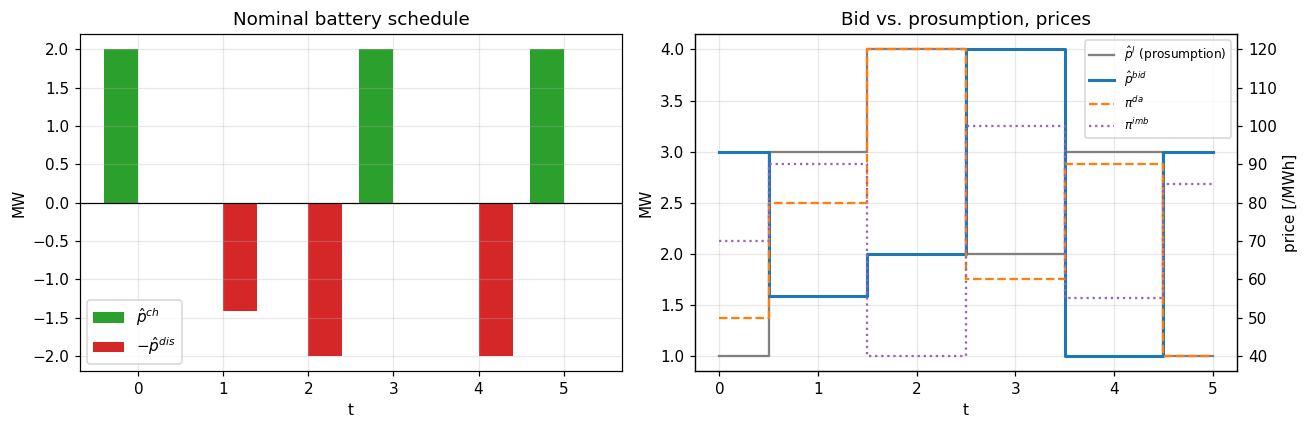

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
t = np.arange(T)

ax1.bar(t - 0.2, v_r.p_ch_hat.value, 0.4, label=r"$\hat p^{ch}$", color="tab:green")
ax1.bar(t + 0.2, -v_r.p_dis_hat.value, 0.4, label=r"$-\hat p^{dis}$", color="tab:red")
ax1.axhline(0, color="k", lw=0.8)
ax1.set(title="Nominal battery schedule", xlabel="t", ylabel="MW")
ax1.legend()

p_bid = P.pl_hat + v_r.p_ch_hat.value - v_r.p_dis_hat.value
ax2.step(t, P.pl_hat, where="mid", label=r"$\hat p^l$ (prosumption)", color="gray")
ax2.step(t, p_bid, where="mid", label=r"$\hat p^{bid}$", color="tab:blue", lw=2)
ax2b = ax2.twinx()
ax2b.step(t, P.pi_da, where="mid", ls="--", color="tab:orange", label=r"$\pi^{da}$")
ax2b.step(t, P.pi_imb, where="mid", ls=":", color="tab:purple", label=r"$\pi^{imb}$")
ax2b.set_ylabel("price [/MWh]"); ax2b.grid(False)
ax2.set(title="Bid vs. prosumption, prices", xlabel="t", ylabel="MW")
h1, l1 = ax2.get_legend_handles_labels(); h2, l2 = ax2b.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, loc="best", fontsize=8)
plt.tight_layout(); plt.show()

## 3. Realised trajectories over the sample scenarios (fan charts)

Every sampled path should respect the physical bounds (samples here are clipped to the box, so violations must be **0** — this is the positive control).

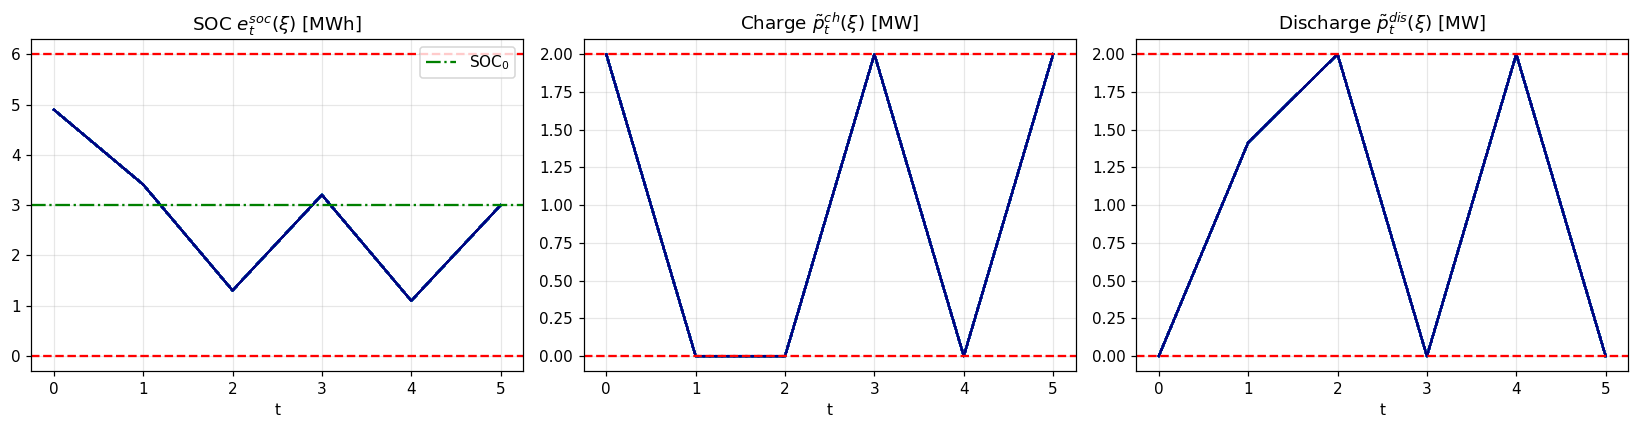

terminal SOC spread across scenarios: 0.00e+00 (should be ~0: g_T = 0 makes it xi-independent)


In [4]:
s_hat, G = _soc_affine(P, v_r)
s_hat_v, G_v = s_hat.value, G.value
X = P.xi_samples
n = X.shape[1]

soc_paths = (s_hat_v[:, None] + G_v @ X)                    # (T, n)
pch_paths = v_r.p_ch_hat.value[:, None]  + v_r.D_ch.value  @ X
pdis_paths = v_r.p_dis_hat.value[:, None] + v_r.D_dis.value @ X

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, paths, lo, hi, title in [
    (axes[0], soc_paths, 0, P.B_max, "SOC $e^{soc}_t(\\xi)$ [MWh]"),
    (axes[1], pch_paths, 0, P.C_ch, "Charge $\\tilde p^{ch}_t(\\xi)$ [MW]"),
    (axes[2], pdis_paths, 0, P.C_dis, "Discharge $\\tilde p^{dis}_t(\\xi)$ [MW]"),
]:
    ax.plot(paths, color="tab:blue", alpha=0.04)
    for q, ls in [(5, ":"), (50, "-"), (95, ":")]:
        ax.plot(np.percentile(paths, q, axis=1), color="navy", ls=ls, lw=1.5)
    ax.axhline(lo, color="r", ls="--"); ax.axhline(hi, color="r", ls="--")
    ax.set(title=title, xlabel="t")
axes[0].axhline(P.SOC0, color="g", ls="-.", label="SOC$_0$"); axes[0].legend()
plt.tight_layout(); plt.show()

print(f"terminal SOC spread across scenarios: {np.ptp(soc_paths[-1, :]):.2e} "
      f"(should be ~0: g_T = 0 makes it xi-independent)")

## 4. Recourse matrices

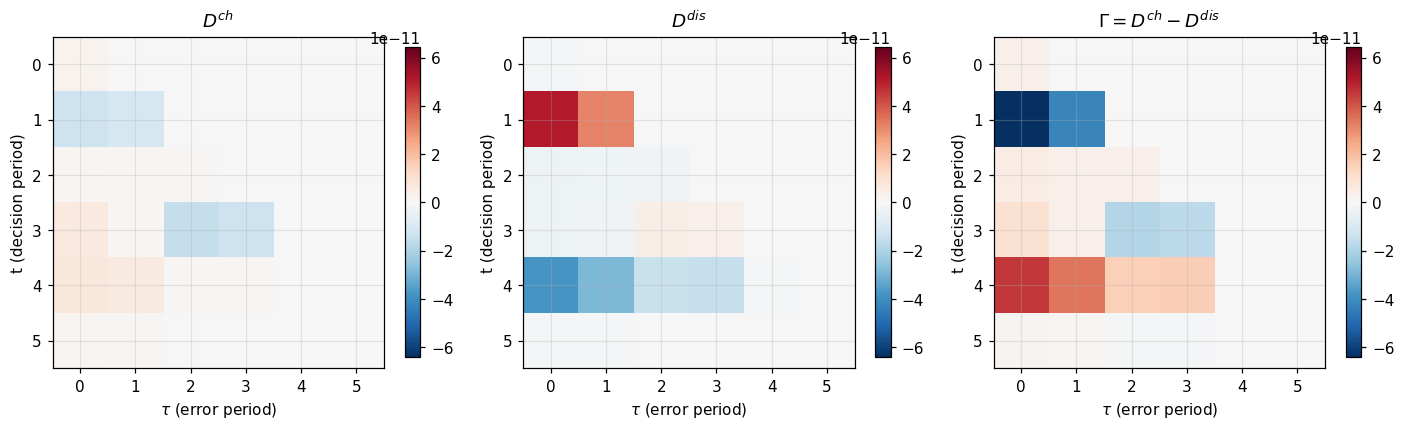

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
mats = [("$D^{ch}$", v_r.D_ch.value), ("$D^{dis}$", v_r.D_dis.value),
        ("$\\Gamma = D^{ch}-D^{dis}$", v_r.D_ch.value - v_r.D_dis.value)]
vmax = max(np.abs(m).max() for _, m in mats) or 1.0
for ax, (name, M) in zip(axes, mats):
    im = ax.imshow(M, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set(title=name, xlabel=r"$\tau$ (error period)", ylabel="t (decision period)")
    fig.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout(); plt.show()

## 5. $\rho$-sweep — the LDR dying as $\Xi'$ widens

The empirical version of *"if the uncertainty set is too wide, no control will take place"*.

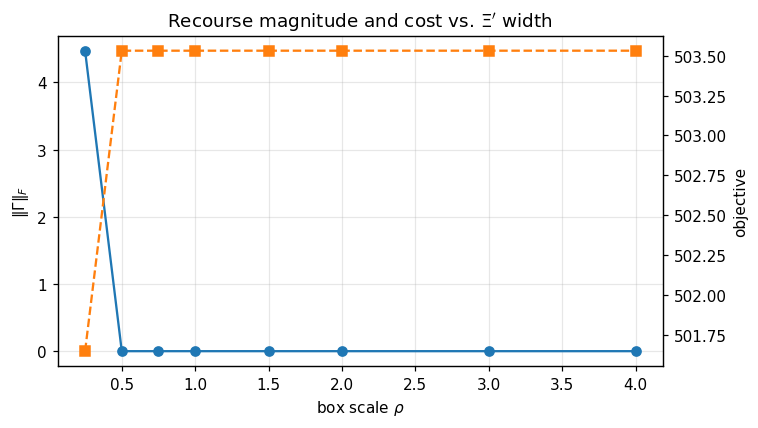

In [6]:
rhos = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0]
norms, objs, statuses = [], [], []
for rho in rhos:
    Pr = replace(P, h_plus=np.full(T, 0.8 * rho), h_minus=np.full(T, 0.8 * rho))
    pr, vr = build_robust(Pr)
    pr.solve(solver=cp.CLARABEL)
    statuses.append(pr.status)
    if vr.D_ch.value is None:
        norms.append(np.nan); objs.append(np.nan)
    else:
        norms.append(np.linalg.norm(vr.D_ch.value - vr.D_dis.value))
        objs.append(pr.value)

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(rhos, norms, "o-", color="tab:blue")
ax1.set(xlabel=r"box scale $\rho$", ylabel=r"$\|\Gamma\|_F$", title=r"Recourse magnitude and cost vs. $\Xi'$ width")
ax2 = ax1.twinx(); ax2.plot(rhos, objs, "s--", color="tab:orange"); ax2.set_ylabel("objective"); ax2.grid(False)
for r, s in zip(rhos, statuses):
    if s != "optimal": ax1.annotate(s, (r, 0), rotation=90, fontsize=7, color="red")
plt.tight_layout(); plt.show()

## 6. $k$-sweep — economics vs. imbalance tracking

Includes $k=0$: expect the degenerate regime (recourse pinned only by constraints + Tikhonov — $\|\Gamma\|_F$ becomes arbitrary/small there, per the Model-2 proposition).

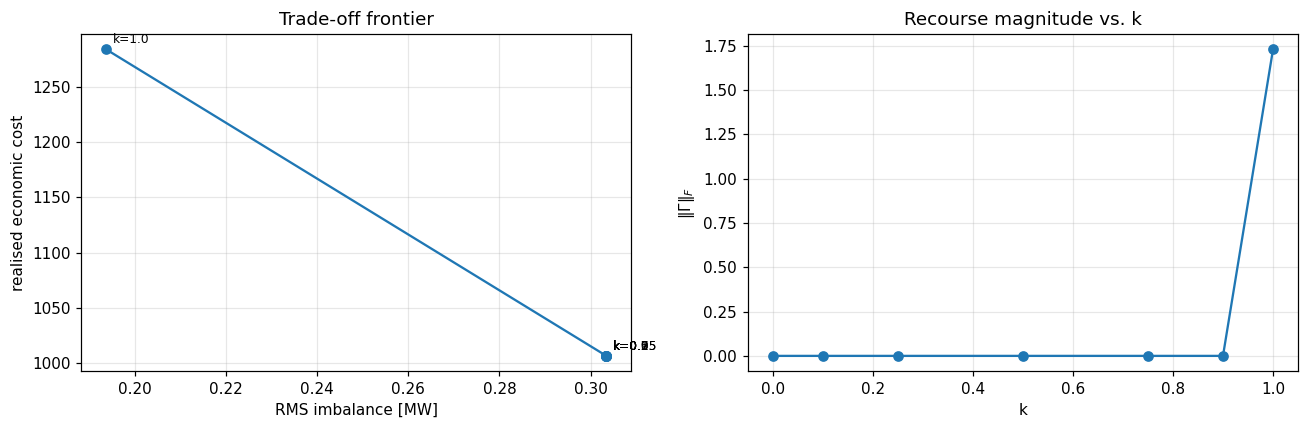

In [7]:
ks = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
econ_costs, imb_rms, g_norms = [], [], []
for k in ks:
    Pk = replace(P, k=k)
    pk, vk = build_robust(Pk)
    pk.solve(solver=cp.CLARABEL)
    Gam = vk.D_ch.value - vk.D_dis.value
    E = (np.eye(T) + Gam) @ P.xi_samples                     # realised imbalance (T, n)
    p_bid_k = P.pl_hat + vk.p_ch_hat.value - vk.p_dis_hat.value
    econ_costs.append(P.pi_da @ p_bid_k * P.dt + (P.pi_imb @ E).mean() * P.dt)
    imb_rms.append(np.sqrt((E**2).mean()))
    g_norms.append(np.linalg.norm(Gam))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(imb_rms, econ_costs, "o-")
for k, x, y in zip(ks, imb_rms, econ_costs):
    axes[0].annotate(f"k={k}", (x, y), fontsize=8, xytext=(4, 4), textcoords="offset points")
axes[0].set(xlabel="RMS imbalance [MW]", ylabel="realised economic cost", title="Trade-off frontier")
axes[1].plot(ks, g_norms, "o-")
axes[1].set(xlabel="k", ylabel=r"$\|\Gamma\|_F$", title="Recourse magnitude vs. k")
plt.tight_layout(); plt.show()

## 7. Wash-flow diagnostic at the box vertices

Nominal wash alone can hide recourse wash; check simultaneous charge/discharge at every corner of $\Xi'$ (64 at $T=6$).

In [8]:
corners = np.array(list(product(*[(P.h_plus[i], -P.h_minus[i]) for i in range(T)])))  # (64, T)
max_wash, worst = 0.0, None
for xi in corners:
    pc = v_r.p_ch_hat.value + v_r.D_ch.value @ xi
    pd = v_r.p_dis_hat.value + v_r.D_dis.value @ xi
    w = np.minimum(pc, pd).max()
    if w > max_wash: max_wash, worst = w, xi

print(f"max simultaneous charge/discharge over all vertices: {max_wash:.6f} MW")
print(f"as fraction of C_ch: {max_wash / P.C_ch:.2%}  (want << 1%)")
if worst is not None and max_wash > 1e-4 * P.C_ch:
    print("worst-case vertex:", worst)
    print("-> non-negligible wash: revisit gamma / consider throughput cost (see formulation notes)")

max simultaneous charge/discharge over all vertices: 0.000000 MW
as fraction of C_ch: 0.00%  (want << 1%)


## Reading the results

- **Cell 1 gap ≈ 0** is the gate: the duality-based robust build and the brute-force oracle define the same feasible set. Anything downstream is only meaningful if this passes.
- **Cell 3**: all fans inside red bounds; terminal SOC spread ~0 (it is $\xi$-independent by $g_T=0$, so *any* spread means the coefficient-matching constraints failed).
- **Cell 5**: $\|\Gamma\|_F \to 0$ as $\rho$ grows — the robust constraints squeezing out the LDR.
- **Cell 6**: at $k=0$ the frontier point reflects the degeneracy proposition (deterministic $\pi^{imb}$, near-zero-mean samples ⇒ recourse unpriced); the frontier's shape from $k>0$ is the meaningful part.
- **Cell 7**: wash should be negligible here (efficiency losses + terminal equality + Tikhonov); if not, the formulation notes give the escalation path.

**Next steps**: swap the toy instance for $T=24$ with copula scenarios and BART quantile bounds (drop the oracle cell above $T\approx10$, or run it once at $T=8$ with real-ish parameters), and re-run cells 2–7 unchanged.